In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [99]:
df = sns.load_dataset('tips')

In [104]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [276]:
# Задание 1 Сравнить доверительные интервалы для total_bill у курящих и некурящих в tips.
# переменные
df_smoker = df[df['smoker'] == 'Yes']['total_bill']
df_smoker_mean = np.mean(df_smoker)
df_not_smoker = df[df['smoker'] == 'No']['total_bill']
df_not_smoker_mean = np.mean(df_not_smoker)
df_smoker_sem = stats.sem(df_smoker)
df_not_smoker_sem = stats.sem(df_not_smoker)

df_smoker_low_bound, df_smoker_high_bound = stats.t.interval(0.95, df=len(df_smoker)-1, loc=df_smoker_mean, scale=df_smoker_sem)
df_not_smoker_low_bound, df_not_smoker_high_bound = stats.t.interval(0.95, df=len(df_not_smoker)-1, loc=df_not_smoker_mean, scale=df_not_smoker_sem)


t-тест для smoker: t=1.34, p=0.182
Cohen's d = -0.17


Text(94.22222222222221, 0.5, 'Количество')

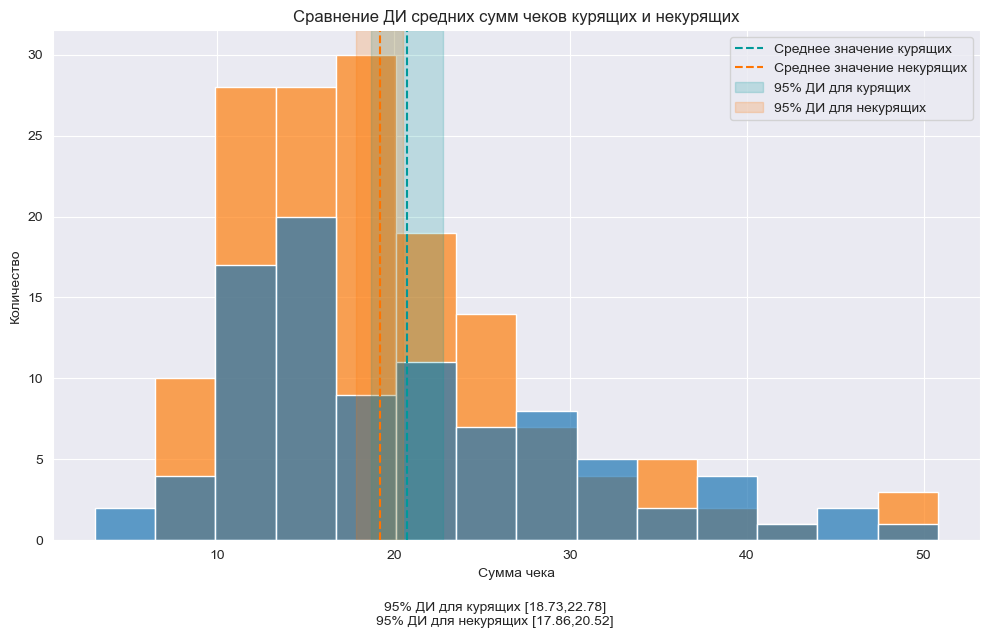

In [278]:
# график
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='total_bill', hue='smoker', alpha=0.7)
ax.axvline(df_smoker_mean, color='#009999', linestyle='--', label='Среднее значение курящих')
ax.axvline(df_not_smoker_mean, color='#FF7400', linestyle='--', label='Среднее значение некурящих')
plt.axvspan(df_smoker_low_bound, df_smoker_high_bound, alpha=0.2, color='#009999', label='95% ДИ для курящих')
plt.axvspan(df_not_smoker_low_bound, df_not_smoker_high_bound, alpha=0.2, color='#FF7400', label='95% ДИ для некурящих')
plt.figtext(0.5, -0.05, f'95% ДИ для курящих [{df_smoker_low_bound:.2f},{df_smoker_high_bound:.2f}]\n95% ДИ для некурящих [{df_not_smoker_low_bound:.2f},{df_not_smoker_high_bound:.2f}]', ha='center')
plt.title('Сравнение ДИ средних сумм чеков курящих и некурящих')
ax.legend()
plt.tight_layout()
plt.xlabel('Сумма чека')
plt.ylabel('Количество')

In [256]:
# Вывод: ДИ пересекаются, следовательно статистически значимых отличий двух групп, курящих и некурящих, нет

In [271]:
# Задание № 2 Сравнить tip у мужчин и женщин в tips с помощью t-теста.
# смотрим на средние групп
df.groupby('sex')['tip'].mean().to_frame().reset_index()
# Нулевая гипотеза - средние двух групп в ГС равны. Альтернативная гипотеза - средние двух групп в ГС неравны

,sex,tip
0,Male,3.089618
1,Female,2.833448


In [273]:
# рассчитываем p-value
_, p_value = stats.ttest_ind(df[df['sex'] == 'Male']['tip'], df[df['sex'] == 'Female']['tip'])

In [274]:
# p_value больше 0.05, следовательно мы не можем опровергнуть нулевую гипотезу
p_value < 0.05

False

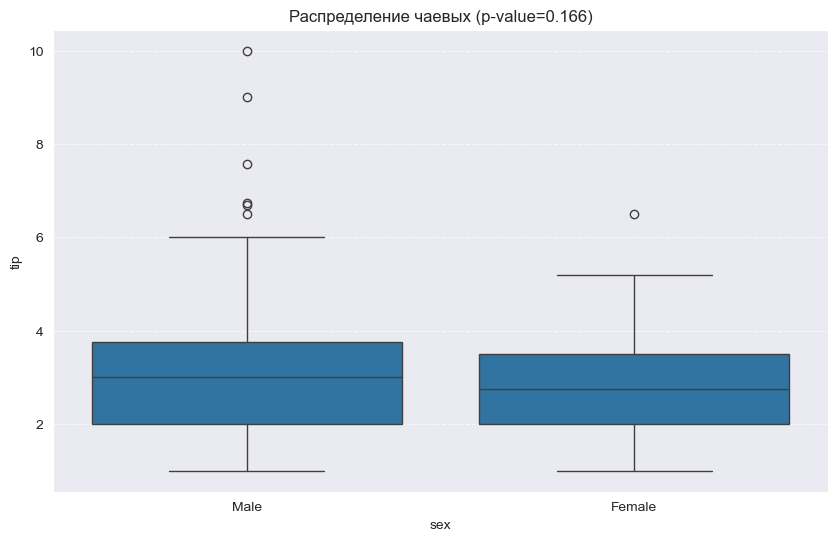

In [277]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='tip', data=df)
plt.title(f"Распределение чаевых (p-value={p_value:.3f})")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()